In [ ]:
import os, sys
sys.path.insert(0, os.path.expanduser("../quick_start"))

In [22]:
from faultSeg.unet3 import unet
import numpy as np
from tensorflow.keras.optimizers import Adam
import copy
import matplotlib.pyplot as plt
import numpy as np
import string
from plotting import plot3d


# Build the exact architecture used in train.py
fseg_model = unet(input_size=(None, None, None, 1))
fseg_model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

geofwi_model = unet(input_size=(None, None, None, 1))
geofwi_model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# load weights into model
fseg_model.load_weights("./faultSeg/check1/fseg.hdf5")

geofwi_model.load_weights("./geofwi/check1/fseg.hdf5")

print("Loaded models and weights from disk")

# training image dimensions
n1, n2, n3 = 96, 96, 96

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, None, None,  0                                            
__________________________________________________________________________________________________
conv3d_30 (Conv3D)              (None, None, None, N 448         input_3[0][0]                    
__________________________________________________________________________________________________
conv3d_31 (Conv3D)              (None, None, None, N 6928        conv3d_30[0][0]                  
__________________________________________________________________________________________________
max_pooling3d_6 (MaxPooling3D)  (None, None, None, N 0           conv3d_31[0][0]                  
____________________________________________________________________________________________

In [23]:
graw = np.fromfile("faultSeg/data/validation/seis/8.dat", dtype=np.single).reshape(128, 128, 128)[:96, :96, :96].T
fault = np.fromfile("faultSeg/data/validation/fault/8.dat", dtype=np.single).reshape(128, 128, 128)[:96, :96, :96].T

graw = (graw - np.mean(graw)) / (np.std(graw) + 1e-8)
x = np.reshape(graw, (1, 96, 96, 96, 1))
Yg = geofwi_model.predict(x, verbose=1)
Yf = fseg_model.predict(x, verbose=1)

1/1 [==============================] - 0s 208ms/step


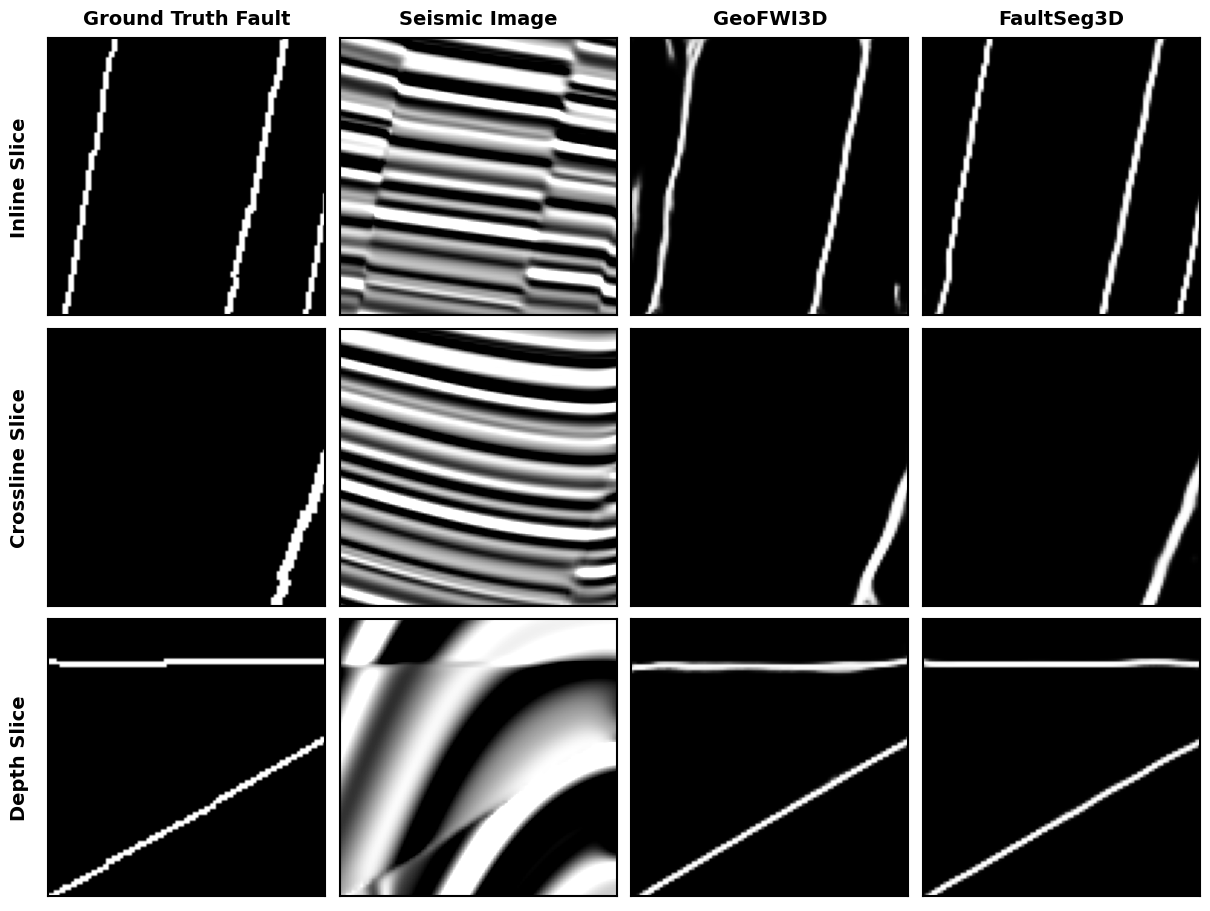

In [24]:
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.linewidth': 1.5,    
    'pdf.fonttype': 42,       
    'ps.fonttype': 42
})


fig, ax = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)

# --- Row 0: Inline Slice ---
ax[0, 0].imshow(fault[:, :, 40], cmap="gray", vmin=0, vmax=1)
ax[0, 1].imshow(graw[:, :, 40], cmap="gray", vmin=-1, vmax=1)
ax[0, 2].imshow(Yg[0, :, :, 40, 0], cmap="gray", vmin=0, vmax=1)
ax[0, 3].imshow(Yf[0, :, :, 40, 0], cmap="gray", vmin=0, vmax=1)

# --- Row 1: Crossline Slice ---
ax[1, 0].imshow(fault[:, 40, :], cmap="gray", vmin=0, vmax=1)
ax[1, 1].imshow(graw[:, 40, :], cmap="gray", vmin=-1, vmax=1)
ax[1, 2].imshow(Yg[0, :, 40, :, 0], cmap="gray", vmin=0, vmax=1)
ax[1, 3].imshow(Yf[0, :, 40, :, 0], cmap="gray", vmin=0, vmax=1)

# --- Row 2: Depth Slice ---
ax[2, 0].imshow(fault[40, :, :], cmap="gray", vmin=0, vmax=1)
ax[2, 1].imshow(graw[40, :, :], cmap="gray", vmin=-1, vmax=1)
ax[2, 2].imshow(Yg[0, 40, :, :, 0], cmap="gray", vmin=0, vmax=1)
ax[2, 3].imshow(Yf[0, 40, :, :, 0], cmap="gray", vmin=0, vmax=1)

col_titles = ["Ground Truth Fault", "Seismic Image", "GeoFWI3D", "FaultSeg3D"]
for i, title in enumerate(col_titles):
    ax[0, i].set_title(title, fontsize=14, weight='bold', pad=10)

row_labels = ["Inline Slice", "Crossline Slice", "Depth Slice"]
for i, label in enumerate(row_labels):
    ax[i, 0].set_ylabel(label, fontsize=14, weight='bold', labelpad=10)

letters = string.ascii_lowercase
for i, axis in enumerate(ax.flat):
    axis.set_xticks([])
    axis.set_yticks([])
    

    # axis.text(0.03, 0.97, f'({letters[i]})', transform=axis.transAxes,
    #           fontsize=12, weight='normal', color='white',
    #           verticalalignment='top', 
    #           bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2.0))

plt.savefig("faultseg-validation.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
num_samples = 20
threshold = 0.5

# Initialize global accumulators
g_tp, g_fp, g_fn = 0, 0, 0
f_tp, f_fp, f_fn = 0, 0, 0

print(f"Starting evaluation on {num_samples} validation samples...\n")

for i in range(num_samples):
    # 1. Dynamically load the files
    seis_path = f"faultSeg/data/validation/seis/{i}.dat"
    fault_path = f"faultSeg/data/validation/fault/{i}.dat"
    
    graw = np.fromfile(seis_path, dtype=np.single).reshape(128, 128, 128)[:96, :96, :96].T
    fault = np.fromfile(fault_path, dtype=np.single).reshape(128, 128, 128)[:96, :96, :96].T

    # 2. Preprocess
    graw = (graw - np.mean(graw)) / (np.std(graw) + 1e-8)
    x = np.reshape(graw, (1, 96, 96, 96, 1))
    
    # 3. Predict (verbose=0 keeps the console clean)
    Yg = geofwi_model.predict(x, verbose=0)
    Yf = fseg_model.predict(x, verbose=0)

    # 4. Flatten and binarize
    y_true = fault.flatten() >= threshold
    pred_g = Yg[0, ..., 0].flatten() >= threshold
    pred_f = Yf[0, ..., 0].flatten() >= threshold

    # 5. Accumulate GeoFWI overlaps
    g_tp += np.sum(pred_g & y_true)
    g_fp += np.sum(pred_g & ~y_true)
    g_fn += np.sum(~pred_g & y_true)

    # 6. Accumulate FaultSeg overlaps
    f_tp += np.sum(pred_f & y_true)
    f_fp += np.sum(pred_f & ~y_true)
    f_fn += np.sum(~pred_f & y_true)
    
    # Progress tracker
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{num_samples} samples...")

# --- Compute Final Dataset-Level Metrics ---
def compute_final_metrics(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    return precision, recall, f1_score, iou

g_prec, g_rec, g_f1, g_iou = compute_final_metrics(g_tp, g_fp, g_fn)
f_prec, f_rec, f_f1, f_iou = compute_final_metrics(f_tp, f_fp, f_fn)

# --- Print Final Results Table ---
print("\n" + "-" * 70)
print(f"{'Global Validation Metrics (50 Samples)':^70}")
print("-" * 70)
print(f"{'Model':<22} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'IoU':<10}")
print("-" * 70)
print(f"{'GeoFWI Prediction':<22} | {g_prec:<10.4f} | {g_rec:<10.4f} | {g_f1:<10.4f} | {g_iou:<10.4f}")
print(f"{'FaultSeg Prediction':<22} | {f_prec:<10.4f} | {f_rec:<10.4f} | {f_f1:<10.4f} | {f_iou:<10.4f}")
print("-" * 70)

Starting evaluation on 20 validation samples...



Processed 10/20 samples...
Processed 20/20 samples...

----------------------------------------------------------------------
                Global Validation Metrics (50 Samples)                
----------------------------------------------------------------------
Model                  | Precision  | Recall     | F1-Score   | IoU       
----------------------------------------------------------------------
GeoFWI Prediction      | 0.4619     | 0.3701     | 0.4110     | 0.2586    
FaultSeg Prediction    | 0.7979     | 0.7840     | 0.7909     | 0.6541    
----------------------------------------------------------------------


In [ ]:
graw = np.fromfile("geofwi/data/validation/seis/8.dat", dtype=np.single).reshape(96, 96, 96).T
fault = np.fromfile("geofwi/data/validation/fault/8.dat", dtype=np.single).reshape(96, 96, 96).T

graw = (graw - np.mean(graw)) / (np.std(graw) + 1e-8)
x = np.reshape(graw, (1, 96, 96, 96, 1))
Yg = geofwi_model.predict(x, verbose=1)
Yf = fseg_model.predict(x, verbose=1)

1/1 [==============================] - 0s 25ms/step


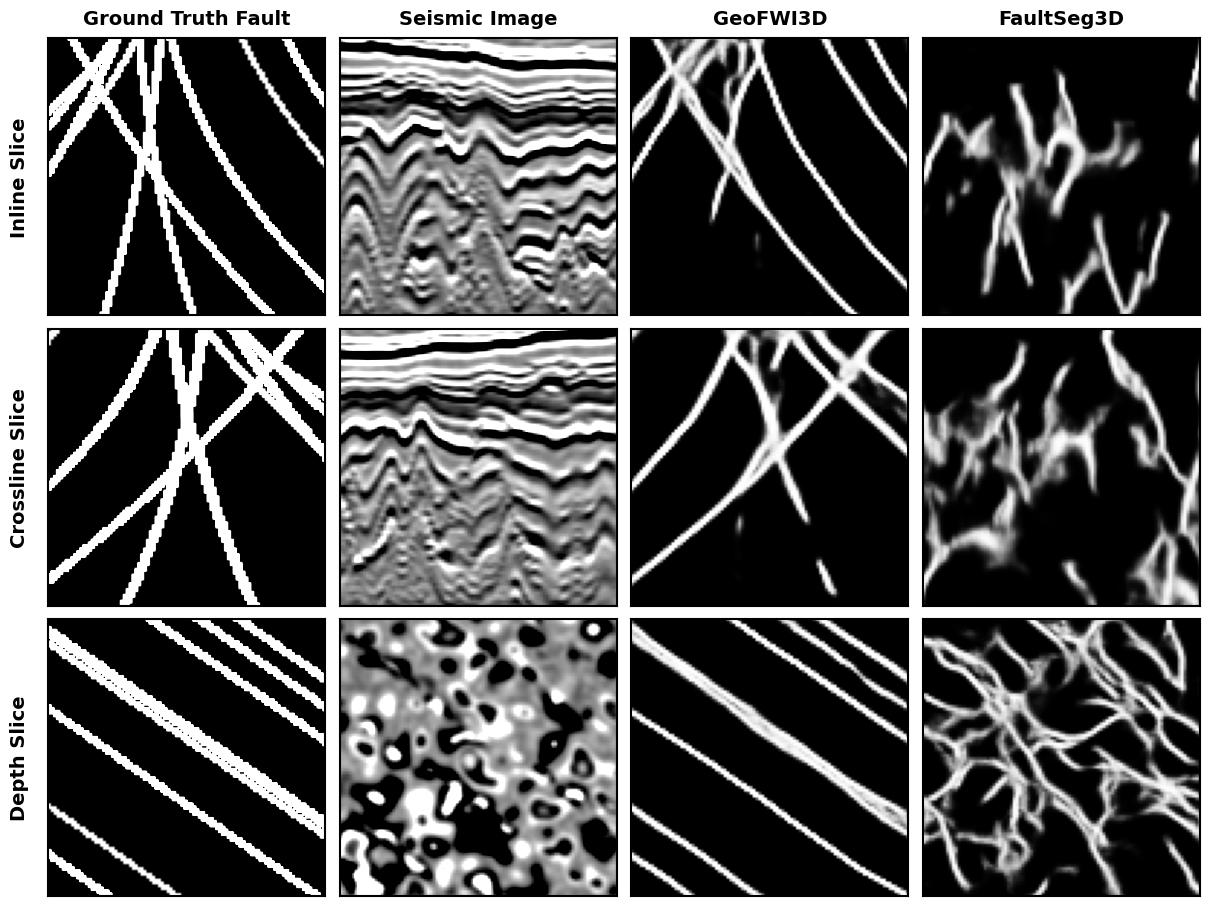

In [28]:
fig, ax = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)

# --- Row 0: Inline Slice ---
ax[0, 0].imshow(fault[:, :, 40], cmap="gray", vmin=0, vmax=1)
ax[0, 1].imshow(graw[:, :, 40], cmap="gray", vmin=-1, vmax=1)
ax[0, 2].imshow(Yg[0, :, :, 40, 0], cmap="gray", vmin=0, vmax=1)
ax[0, 3].imshow(Yf[0, :, :, 40, 0], cmap="gray", vmin=0, vmax=1)

# --- Row 1: Crossline Slice ---
ax[1, 0].imshow(fault[:, 40, :], cmap="gray", vmin=0, vmax=1)
ax[1, 1].imshow(graw[:, 40, :], cmap="gray", vmin=-1, vmax=1)
ax[1, 2].imshow(Yg[0, :, 40, :, 0], cmap="gray", vmin=0, vmax=1)
ax[1, 3].imshow(Yf[0, :, 40, :, 0], cmap="gray", vmin=0, vmax=1)

# --- Row 2: Depth Slice ---
ax[2, 0].imshow(fault[40, :, :], cmap="gray", vmin=0, vmax=1)
ax[2, 1].imshow(graw[40, :, :], cmap="gray", vmin=-1, vmax=1)
ax[2, 2].imshow(Yg[0, 40, :, :, 0], cmap="gray", vmin=0, vmax=1)
ax[2, 3].imshow(Yf[0, 40, :, :, 0], cmap="gray", vmin=0, vmax=1)

col_titles = ["Ground Truth Fault", "Seismic Image", "GeoFWI3D", "FaultSeg3D"]
for i, title in enumerate(col_titles):
    ax[0, i].set_title(title, fontsize=14, weight='bold', pad=10)

row_labels = ["Inline Slice", "Crossline Slice", "Depth Slice"]
for i, label in enumerate(row_labels):
    ax[i, 0].set_ylabel(label, fontsize=14, weight='bold', labelpad=10)

letters = string.ascii_lowercase
for i, axis in enumerate(ax.flat):
    axis.set_xticks([])
    axis.set_yticks([])
    

    # axis.text(0.03, 0.97, f'({letters[i]})', transform=axis.transAxes,
    #           fontsize=12, weight='normal', color='Red',
    #           verticalalignment='top', 
    #           bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2.0))

plt.savefig("geofwi-validation.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
num_samples = 20
threshold = 0.5

# Initialize global accumulators
g_tp, g_fp, g_fn = 0, 0, 0
f_tp, f_fp, f_fn = 0, 0, 0

print(f"Starting evaluation on {num_samples} validation samples...\n")

for i in range(num_samples):
    # 1. Dynamically load the files
    seis_path = f"geofwi/data/validation/seis/{i}.dat"
    fault_path = f"geofwi/data/validation/fault/{i}.dat"
    
    graw = np.fromfile(seis_path, dtype=np.single).reshape(96, 96, 96).T
    fault = np.fromfile(fault_path, dtype=np.single).reshape(96, 96, 96).T

    # 2. Preprocess
    graw = (graw - np.mean(graw)) / (np.std(graw) + 1e-8)
    x = np.reshape(graw, (1, 96, 96, 96, 1))
    
    # 3. Predict (verbose=0 keeps the console clean)
    Yg = geofwi_model.predict(x, verbose=0)
    Yf = fseg_model.predict(x, verbose=0)

    # 4. Flatten and binarize
    y_true = fault.flatten() >= threshold
    pred_g = Yg[0, ..., 0].flatten() >= threshold
    pred_f = Yf[0, ..., 0].flatten() >= threshold

    # 5. Accumulate GeoFWI overlaps
    g_tp += np.sum(pred_g & y_true)
    g_fp += np.sum(pred_g & ~y_true)
    g_fn += np.sum(~pred_g & y_true)

    # 6. Accumulate FaultSeg overlaps
    f_tp += np.sum(pred_f & y_true)
    f_fp += np.sum(pred_f & ~y_true)
    f_fn += np.sum(~pred_f & y_true)
    
    # Progress tracker
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{num_samples} samples...")

g_prec, g_rec, g_f1, g_iou = compute_final_metrics(g_tp, g_fp, g_fn)
f_prec, f_rec, f_f1, f_iou = compute_final_metrics(f_tp, f_fp, f_fn)

# --- Print Final Results Table ---
print("\n" + "-" * 70)
print(f"{'Global Validation Metrics (50 Samples)':^70}")
print("-" * 70)
print(f"{'Model':<22} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'IoU':<10}")
print("-" * 70)
print(f"{'GeoFWI Prediction':<22} | {g_prec:<10.4f} | {g_rec:<10.4f} | {g_f1:<10.4f} | {g_iou:<10.4f}")
print(f"{'FaultSeg Prediction':<22} | {f_prec:<10.4f} | {f_rec:<10.4f} | {f_f1:<10.4f} | {f_iou:<10.4f}")
print("-" * 70)

Starting evaluation on 20 validation samples...

Processed 10/20 samples...


Processed 20/20 samples...

----------------------------------------------------------------------
                Global Validation Metrics (50 Samples)                
----------------------------------------------------------------------
Model                  | Precision  | Recall     | F1-Score   | IoU       
----------------------------------------------------------------------
GeoFWI Prediction      | 0.7920     | 0.7624     | 0.7769     | 0.6352    
FaultSeg Prediction    | 0.4975     | 0.2171     | 0.3023     | 0.1781    
----------------------------------------------------------------------


In [31]:
# set gaussian weights in overlap boundaries for current patch size
def getMask(os, n1, n2, n3):
    sc = np.zeros((n1, n2, n3), dtype=np.single)
    sc = sc + 1
    sp = np.zeros((os), dtype=np.single)
    sig = os / 4
    sig = 0.5 / (sig * sig)
    for ks in range(os):
        ds = ks - os + 1
        sp[ks] = np.exp(-ds * ds * sig)
    for k1 in range(os):
        for k2 in range(n2):
            for k3 in range(n3):
                sc[k1][k2][k3] = sp[k1]
                sc[n1 - k1 - 1][k2][k3] = sp[k1]
    for k1 in range(n1):
        for k2 in range(os):
            for k3 in range(n3):
                sc[k1][k2][k3] = sp[k2]
                sc[k1][n2 - k2 - 1][k3] = sp[k2]
    for k1 in range(n1):
        for k2 in range(n2):
            for k3 in range(os):
                sc[k1][k2][k3] = sp[k3]
                sc[k1][k2][n3 - k3 - 1] = sp[k3]
    return sc

In [32]:
gx, m1, m2, m3 = np.fromfile("./faultSeg/data/prediction/f3d/gxl.dat", dtype=np.single), 512, 384, 128
os_width = 12 # overlap width

c1 = int(np.round((m1 + os_width) / (n1 - os_width) + 0.5))
c2 = int(np.round((m2 + os_width) / (n2 - os_width) + 0.5))
c3 = int(np.round((m3 + os_width) / (n3 - os_width) + 0.5))

p1 = (n1 - os_width) * c1 + os_width
p2 = (n2 - os_width) * c2 + os_width
p3 = (n3 - os_width) * c3 + os_width

gx = np.reshape(gx, (m1, m2, m3))
gp = np.zeros((p1, p2, p3), dtype=np.single)

# Initialize separate accumulators for both models
gy_geofwi = np.zeros((p1, p2, p3), dtype=np.single)
gy_fseg = np.zeros((p1, p2, p3), dtype=np.single)

# Only one mask accumulator is needed since the geometry is identical
mk = np.zeros((p1, p2, p3), dtype=np.single)

gp[0:m1, 0:m2, 0:m3] = gx
sc = getMask(os_width, n1, n2, n3)

gs = np.zeros((1, n3, n2, n1, 1), dtype=np.single)

for k1 in range(c1):
    for k2 in range(c2):
        for k3 in range(c3):
            b1 = k1 * n1 - k1 * os_width
            e1 = b1 + n1
            b2 = k2 * n2 - k2 * os_width
            e2 = b2 + n2
            b3 = k3 * n3 - k3 * os_width
            e3 = b3 + n3
            
            # Extract patch in (x, y, z)
            patch = gp[b1:e1, b2:e2, b3:e3]
            
            # Preprocessing 
            patch = patch - np.mean(patch)
            patch = patch / (np.std(patch) + 1e-8)
            
            # Transpose to (z, y, x)
            patch = np.transpose(patch)
            gs[0, :, :, :, 0] = patch
            
            # SAFEGUARD 1: Pass a strict copy of gs to Model 1
            Y_geofwi = geofwi_model.predict(np.copy(gs), verbose=0)
            y_patch_geofwi = np.transpose(np.array(Y_geofwi)[0, :, :, :, 0])
            
            # SAFEGUARD 2: Pass a strict copy of gs to Model 2
            Y_fseg = fseg_model.predict(np.copy(gs), verbose=0)
            y_patch_fseg = np.transpose(np.array(Y_fseg)[0, :, :, :, 0])
            
            # Safely multiply by mask and accumulate separately
            gy_geofwi[b1:e1, b2:e2, b3:e3] += y_patch_geofwi * sc
            gy_fseg[b1:e1, b2:e2, b3:e3] += y_patch_fseg * sc
            
            # Accumulate mask once
            mk[b1:e1, b2:e2, b3:e3] += sc

# Normalize overlap
gy_geofwi = gy_geofwi / mk
gy_fseg = gy_fseg / mk

# Trim to original dimensions
gy_geofwi = gy_geofwi[0:m1, 0:m2, 0:m3]
gy_fseg = gy_fseg[0:m1, 0:m2, 0:m3]

gy_geofwi = gy_geofwi.T
gy_fseg = gy_fseg.T
gx = gx.T

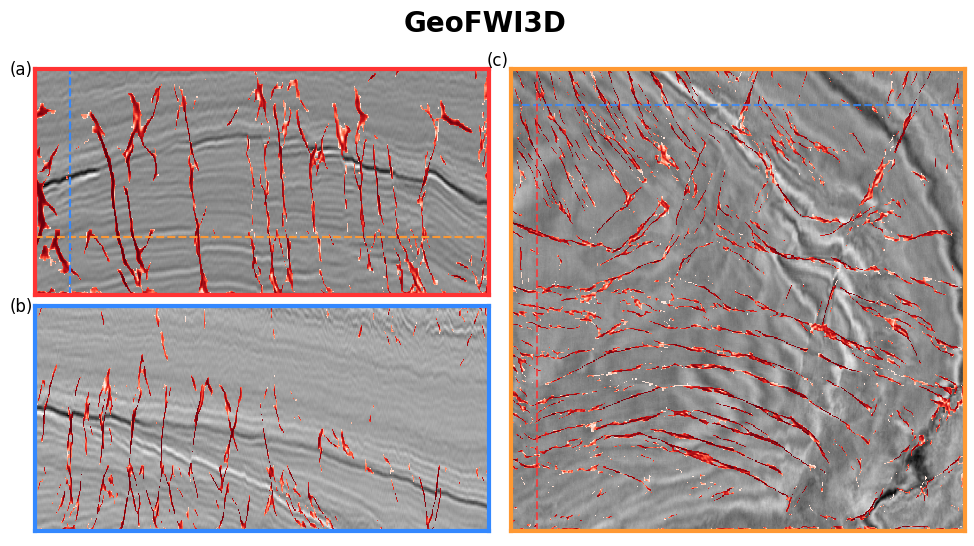

In [33]:
sl_i = 29  # Inline slice
sl_x = 29 # Crossline slice
sl_d = 95 # Depth slice

c_inline = '#FF3333'  # Red for Inline
c_cross  = '#3388FF'  # Blue for Crossline
c_depth  = '#FF9933'  # Orange for Depth

fig = plt.figure(figsize=(12, 6))

# Crush the spacing between subplots to 5% (or set to 0.0 for seamless)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.05, hspace=0.05)

ax_inline = fig.add_subplot(gs[0, 0])
ax_cross  = fig.add_subplot(gs[1, 0])
ax_depth  = fig.add_subplot(gs[:, 1])

# 3. Plot Data with aspect='auto' to force them to fill the panels
ax_inline.imshow(gx[:, :, sl_i], cmap="gray", aspect='auto')
ax_cross.imshow(gx[:, sl_x, :], cmap="gray", aspect='auto')
ax_depth.imshow(gx[sl_d, :, :], cmap="gray", aspect='auto')

gy_geofwi_threshold = gy_geofwi.copy()
gy_geofwi_threshold[gy_geofwi_threshold < .4] = np.nan

ax_inline.imshow(gy_geofwi_threshold[:, :, sl_i], cmap="Reds", aspect='auto')
ax_cross.imshow(gy_geofwi_threshold[:, sl_x, :], cmap="Reds", aspect='auto')
ax_depth.imshow(gy_geofwi_threshold[sl_d, :, :], cmap="Reds", aspect='auto')


ax_inline.axhline(sl_d, color=c_depth, linestyle='--', linewidth=1.5, alpha=0.8) # Depth intersection
ax_inline.axvline(sl_x, color=c_cross, linestyle='--', linewidth=1.5, alpha=0.8)
ax_inline.axhline(sl_d, color=c_depth, linestyle='--', linewidth=1.5, alpha=0.8) # Depth intersection
ax_inline.axvline(sl_x, color=c_cross, linestyle='--', linewidth=1.5, alpha=0.8) # Crossline intersection
ax_depth.axhline(sl_x, color=c_cross, linestyle='--', linewidth=1.5, alpha=0.8)  # Crossline intersection
ax_depth.axvline(sl_i, color=c_inline, linestyle='--', linewidth=1.5, alpha=0.8)

def color_borders(ax, color, width=3):
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(width)

color_borders(ax_inline, c_inline)
color_borders(ax_cross, c_cross)
color_borders(ax_depth, c_depth)

# 5. Format Axes & Add Panel Letters
axes = [ax_inline, ax_cross, ax_depth]
letters = string.ascii_lowercase

for i, axis in enumerate(axes):
    axis.set_xticks([])
    axis.set_yticks([])
    
    # Add (a), (b), (c) to the top left of each panel
    axis.text(- 0.055, 1.04, f'({letters[i]})', transform=axis.transAxes,
              fontsize=12, weight='normal', color='black', # Changed to black if background is very white
              verticalalignment='top')


# plt.tight_layout()
plt.suptitle("GeoFWI3D", fontsize=20, weight='bold')
plt.show()

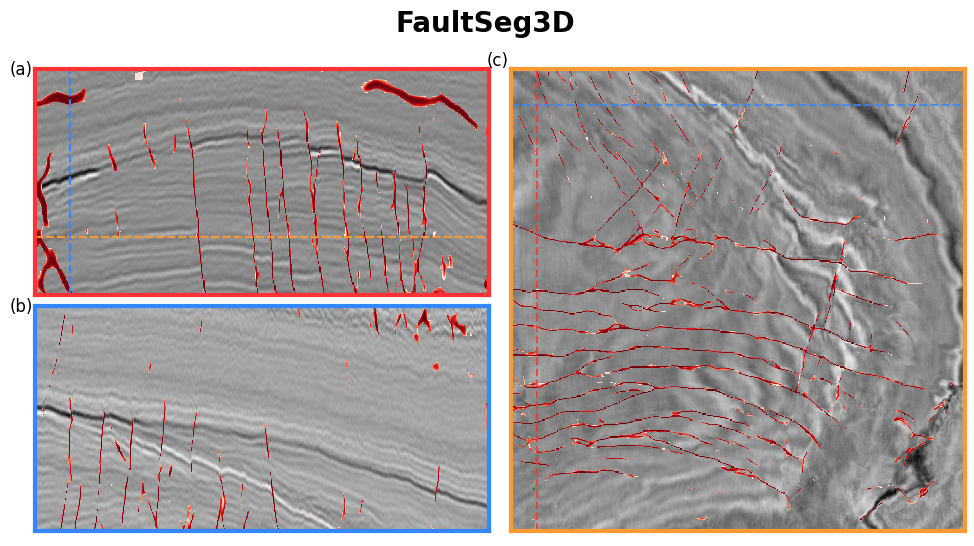

In [34]:
fig = plt.figure(figsize=(12, 6))

# Crush the spacing between subplots to 5% (or set to 0.0 for seamless)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.05, hspace=0.05)

ax_inline = fig.add_subplot(gs[0, 0])
ax_cross  = fig.add_subplot(gs[1, 0])
ax_depth  = fig.add_subplot(gs[:, 1])

# 3. Plot Data with aspect='auto' to force them to fill the panels
ax_inline.imshow(gx[:, :, sl_i], cmap="gray", aspect='auto')
ax_cross.imshow(gx[:, sl_x, :], cmap="gray", aspect='auto')
ax_depth.imshow(gx[sl_d, :, :], cmap="gray", aspect='auto')

gy_fseg_threshold = gy_fseg.copy()
gy_fseg_threshold[gy_fseg_threshold < .4] = np.nan

ax_inline.imshow(gy_fseg_threshold[:, :, sl_i], cmap="Reds", aspect='auto')
ax_cross.imshow(gy_fseg_threshold[:, sl_x, :], cmap="Reds", aspect='auto')
ax_depth.imshow(gy_fseg_threshold[sl_d, :, :], cmap="Reds", aspect='auto')

ax_inline.axhline(sl_d, color=c_depth, linestyle='--', linewidth=1.5, alpha=0.8) # Depth intersection
ax_inline.axvline(sl_x, color=c_cross, linestyle='--', linewidth=1.5, alpha=0.8)
ax_inline.axhline(sl_d, color=c_depth, linestyle='--', linewidth=1.5, alpha=0.8) # Depth intersection
ax_inline.axvline(sl_x, color=c_cross, linestyle='--', linewidth=1.5, alpha=0.8) # Crossline intersection
ax_depth.axhline(sl_x, color=c_cross, linestyle='--', linewidth=1.5, alpha=0.8)  # Crossline intersection
ax_depth.axvline(sl_i, color=c_inline, linestyle='--', linewidth=1.5, alpha=0.8)

def color_borders(ax, color, width=3):
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(width)

color_borders(ax_inline, c_inline)
color_borders(ax_cross, c_cross)
color_borders(ax_depth, c_depth)

# 5. Format Axes & Add Panel Letters
axes = [ax_inline, ax_cross, ax_depth]
letters = string.ascii_lowercase

for i, axis in enumerate(axes):
    axis.set_xticks([])
    axis.set_yticks([])
    
    # Add (a), (b), (c) to the top left of each panel
    axis.text(- 0.055, 1.04, f'({letters[i]})', transform=axis.transAxes,
              fontsize=12, weight='normal', color='black', # Changed to black if background is very white
              verticalalignment='top')


# plt.tight_layout()
plt.suptitle("FaultSeg3D", fontsize=20, weight='bold')
plt.show()

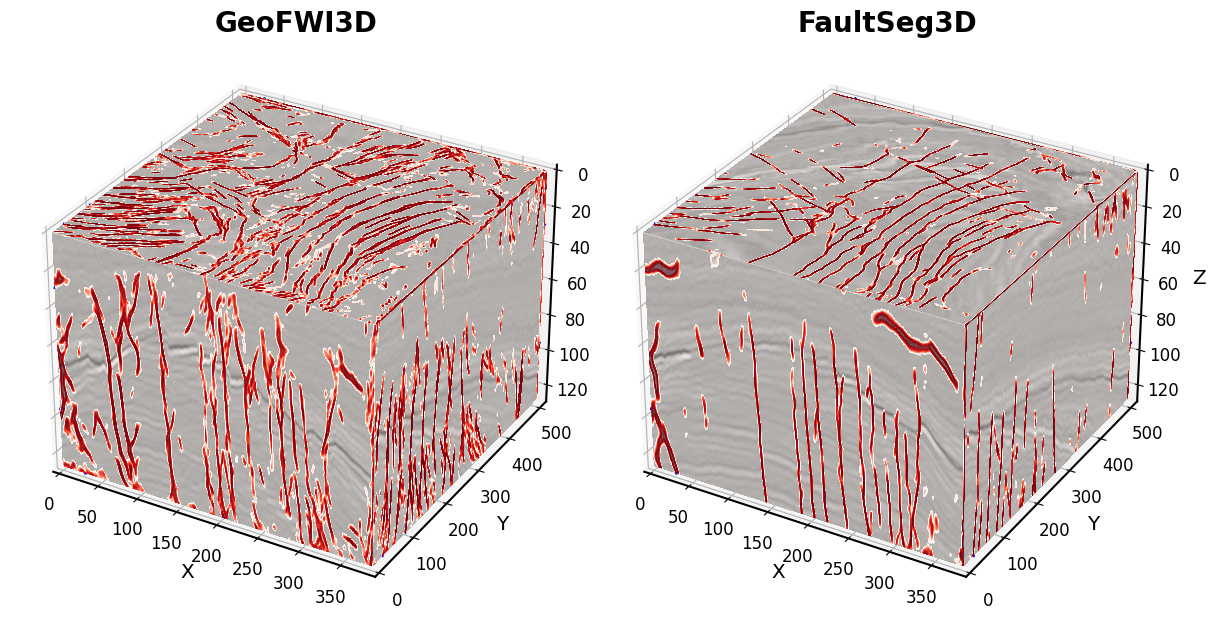

: 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8), subplot_kw={"projection": "3d"})

plt.sca(ax[0])
plot3d(
    gx,
    cmap=plt.cm.gray,
    frames=[sl_i, sl_x, sl_d],
    ifnewfig=False,
    ifinside=False,
    alpha=1.0,
    showf=False,
    close=False,
)

gy_geofwi_threshold = gy_geofwi.copy()
gy_geofwi_threshold[gy_geofwi_threshold < .4] = 0.0

plot3d(
    gy_geofwi_threshold,
    cmap=plt.cm.Reds,
    frames=[sl_d, sl_x, sl_i],
    ifnewfig=False,
    ifinside=False,
    alpha=0.35,
    showf=False,
    close=False,
    ifslice=True,
    vmin=0.4, vmax=1.0
)

plt.sca(ax[1])
plot3d(
    gx,
    cmap=plt.cm.gray,
    frames=[sl_d, sl_x, sl_i],
    ifnewfig=False,
    ifinside=False,
    alpha=1.0,
    showf=False,
    close=False,
)

gy_fseg_threshold = gy_fseg.copy()
gy_fseg_threshold[gy_fseg_threshold < .4] = 0.0

plot3d(
    gy_fseg_threshold,
    cmap=plt.cm.Reds,
    frames=[sl_d, sl_x, sl_i],
    ifnewfig=False,
    ifinside=False,
    alpha=0.35,
    showf=False,
    close=False,
    ifslice=True,
    vmin=0.4, vmax=1.0
)

ax[0].set_title("GeoFWI3D", fontsize=20, weight='bold')
ax[1].set_title("FaultSeg3D", fontsize=20, weight='bold')

ax[0].set_rasterized(True)
ax[1].set_rasterized(True)

plt.tight_layout()

plt.savefig("f3-pred3d.pdf", dpi=300, bbox_inches='tight')
plt.show()